# Prerequisities
In this section we install all necerssary libraries and and import them. Additionally, we also set up the config to use for the training later on.

## Installation Block

In [ ]:
%pip install datasets
%pip install diffusers
%pip install Pillow
%pip install PIL
%pip install torch==2.0.1+cu117 torchvision==0.15.2+cu117 torchaudio==2.0.2+cu117 --extra-index-url https://download.pytorch.org/whl/cu117 --no-cache-dir --user
%pip install numpy==1.26.4
%pip install accelerate
%pip install torch_ema
%pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 474.3/474.3 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 17.2 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 14.0.2
    Uninstalling pyarrow-14.0.2:
      Successfully uninstalled pyarrow-14.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 24.4.1 requires pyarrow<15.0.0a0,>=14.0.1, but you have pyarrow 17.0.0 which is incompatible.
ibis-framework 8.0.0 requires pyarrow<16,>=2, but you have pyarrow 17.0.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 55.3 MB

## Import Block

In [ ]:
import torch
from datasets import load_dataset
import torchvision
import PIL
import json
from torchvision import transforms
import matplotlib.pyplot as plt
from PIL import Image
from diffusers import DDPMScheduler
from diffusers.optimization import get_cosine_schedule_with_warmup
from visualisation import Visualisation
visualisation = Visualisation()

## Training Configuration

In [ ]:
from dataclasses import dataclass

# Setup the traning config
@dataclass
class TrainingConfig:
    image_size = 28  # the generated image resolution - 28px to fit the original images
    train_batch_size = 64
    eval_batch_size = 64  # how many images to sample during evaluation
    num_epochs = 41
    gradient_accumulation_steps = 1
    learning_rate = 1e-4
    lr_warmup_steps = 500
    save_image_epochs = 1
    mixed_precision='fp16' # this
    device_placement=True
    model_output_dir = "./models/"
    results_output_dir = "./results"  # the model name locally and on the HF Hub
    overwrite_output_dir = True  # overwrite the old model when re-running the notebook
    seed = 0
    num_inference_steps = 500

config = TrainingConfig()

# Data

In [ ]:
# Load the data from HuggingFace
ds = load_dataset("ylecun/mnist")
train_dataset = load_dataset("ylecun/mnist", split="train[:100%]")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/6.97k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/15.6M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/2.60M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

## Preprocessing


In [ ]:
# General preprocessing for later randomisation of the dataset
preprocess = transforms.Compose(
    [
        transforms.Resize((config.image_size, config.image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)

def transform_to_grayscale(examples):
    # convert to grayscale to improve performance
    # also use the general preprocessing defined above
    images = [preprocess(image.convert("L")) for image in examples["image"]]
    return {"images": images}


train_dataset.set_transform(transform_to_grayscale)

In [ ]:
# convert to PyTorch data loader object for later training
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=config.train_batch_size, shuffle=True)

## Model Components

In [ ]:
from diffusers import UNet2DModel

# define the Unet neural network
model = UNet2DModel(
    sample_size=28,  # target image resolution
    in_channels=1,  # the number of input channels, 1 to fit greyscale images
    out_channels=1,  # the number of output channels
    layers_per_block=2,  # how many ResNet layers to use per UNet block
    block_out_channels=(32,64,128,),  # the number of output channels for each UNet block
    down_block_types=(
        "DownBlock2D",  # a regular ResNet downsampling block
        "DownBlock2D",
        "AttnDownBlock2D",  # a ResNet downsampling block with spatial self-attention
    ),
    up_block_types=(
        "AttnUpBlock2D",  # a ResNet upsampling block with spatial self-attention
        "UpBlock2D",  # a regular ResNet upsampling block
        "UpBlock2D",
    ),
)

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

In [ ]:
# Check if the shape of input img and model output match
sample_image = train_dataset[0]["images"].unsqueeze(0)
print("Input shape:", sample_image.shape)
print("Output shape:", model(sample_image, timestep=0).sample.shape)

Input shape: torch.Size([1, 1, 28, 28])
Output shape: torch.Size([1, 1, 28, 28])


In [ ]:
# Initialise all necerssary model components:

# First:  noise schedular
noise_scheduler = DDPMScheduler(num_train_timesteps=config.num_inference_steps,
    beta_start=0.0001,         # Start value of beta
    beta_end=0.02,             # End value of beta
    beta_schedule="linear" )

# Second and Third: optimizer and learning rate scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)
lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=config.lr_warmup_steps,
    num_training_steps=(len(train_dataloader) * config.num_epochs),
)

# Training
In this code section we initialise the training loop and its evaluation function and execute the training loop, in case there is no pretrained model.

In [ ]:
from diffusers import DDPMPipeline
import math
import os
import numpy as np

def evaluate(config, epoch, images):
    # Evaluate current results of an epoch through visualising them
    test_dir = os.path.join(config.results_output_dir, "training_samples")
    os.makedirs(test_dir, exist_ok=True)
    path = f"{test_dir}/{epoch:04d}.png"
    visualisation.show_results(images, path)

def save_epoch_losses_to_file(epoch_losses, file_path):
    with open(file_path, 'w') as f:
        json.dump(epoch_losses, f)

## Training Loop

In [ ]:
from accelerate import Accelerator
from huggingface_hub import HfFolder, Repository, whoami
from tqdm.auto import tqdm
from pathlib import Path
import os
import torch.nn.functional as F


def train_loop(config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler):
    # Initialize accelerator
    accelerator = Accelerator(
        mixed_precision=config.mixed_precision,
        gradient_accumulation_steps=config.gradient_accumulation_steps,
    )


    #Pprepare everything
    model, optimizer, train_dataloader, lr_scheduler = accelerator.prepare(
        model, optimizer, train_dataloader, lr_scheduler
    )

    global_step = 0
    epoch_losses = []  # List to store average loss per epoch

    # Now train the model
    for epoch in range(config.num_epochs):
        progress_bar = tqdm(total=len(train_dataloader), disable=not accelerator.is_local_main_process)
        progress_bar.set_description(f"Epoch {epoch}")

        epoch_loss = 0
        num_batches = 0

        for step, batch in enumerate(train_dataloader):
            clean_images = batch["images"]
            noise = torch.randn(clean_images.shape).to(clean_images.device)
            bs = clean_images.shape[0]

            # Sample a random timestep for each image
            timesteps = torch.randint(
                0, noise_scheduler.config.num_train_timesteps, (bs,), device=clean_images.device
            ).long()

            # Add noise to the clean images (forward diffusion process)
            noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

            with accelerator.accumulate(model):
                # Predict the noise residual and compute the loss
                noise_pred = model(noisy_images, timesteps, return_dict=False)[0]
                loss = F.mse_loss(noise_pred, noise)
                accelerator.backward(loss)

                accelerator.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                lr_scheduler.step()
                optimizer.zero_grad()

            # Accumulate loss
            epoch_loss += loss.item()
            num_batches += 1

            logs = {"loss": loss.detach().item(), "lr": lr_scheduler.get_last_lr()[0], "step": global_step}
            if global_step % 10 == 0:
                progress_bar.update(10)
                progress_bar.set_postfix(**logs)

            global_step += 1

        # Compute and store average loss for the epoch
        avg_epoch_loss = epoch_loss / num_batches
        epoch_losses.append(avg_epoch_loss)

        # Sample images to evaluate the results after each epoch
        if epoch == 1 or epoch % 5 == 0 or  epoch == config.num_epochs:
          # not for every epoch though due to performance

            if accelerator.is_main_process:
                pipeline = DDPMPipeline(unet=accelerator.unwrap_model(model), scheduler=noise_scheduler)

            if (epoch + 1) % config.save_image_epochs == 0 or epoch == config.num_epochs - 1:
                images = pipeline(
                batch_size=16,
                num_inference_steps=500).images

                evaluate(config, epoch, images)

    # Save the average loss per epoch to a file after training
    epoch_loss_file_path = os.path.join(config.results_output_dir, "epoch_losses.json")
    save_epoch_losses_to_file(epoch_losses, epoch_loss_file_path)



## Training Initialisation
Check if there is already a pre-trained model, if not, execute the training loop.

Training new model...
Launching training on one GPU.


/usr/local/lib/python3.10/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
/usr/local/lib/python3.10/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

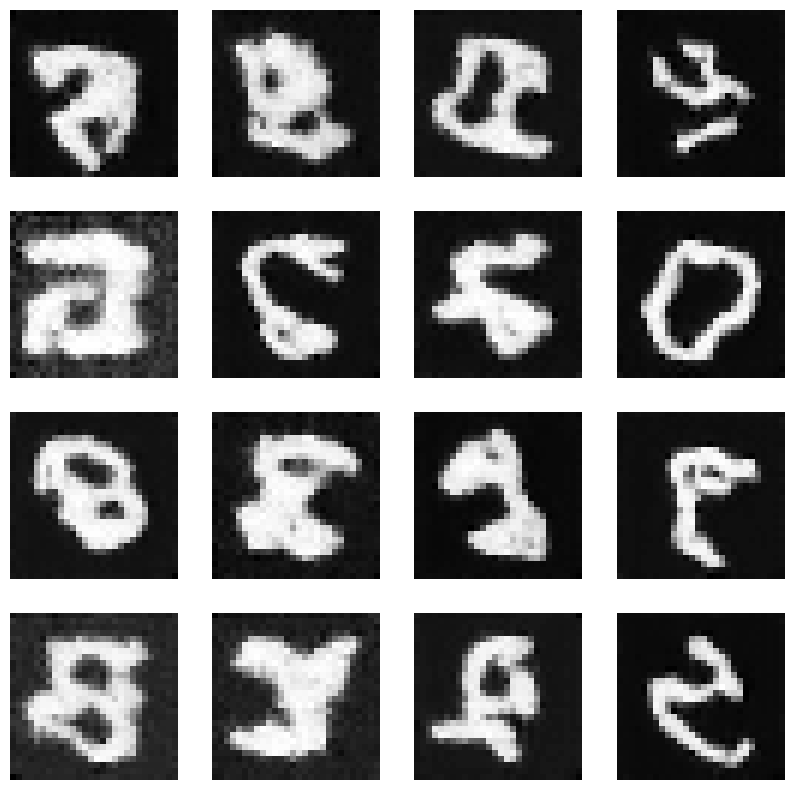

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

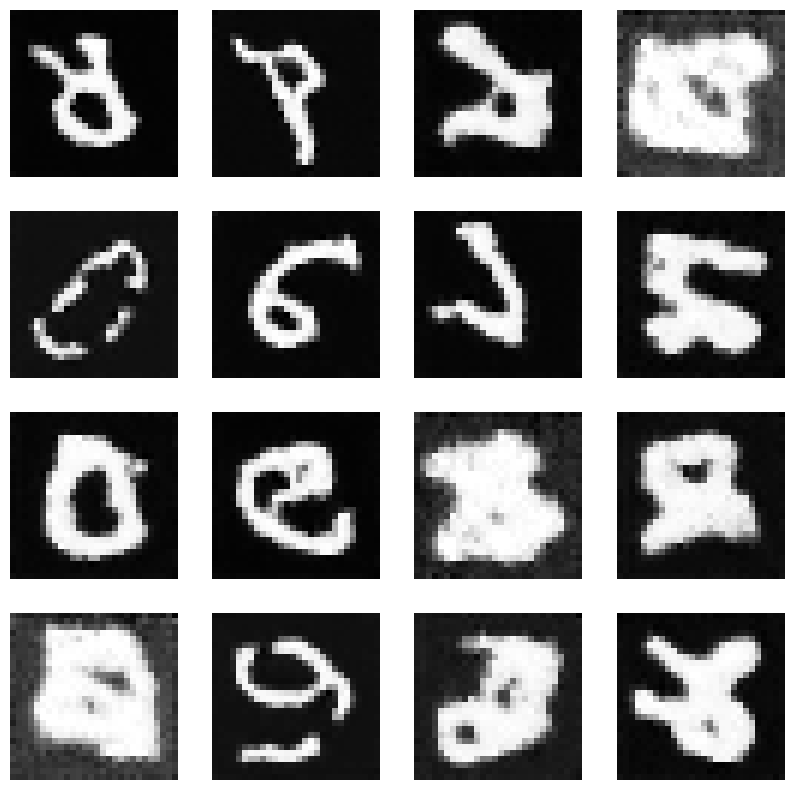

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

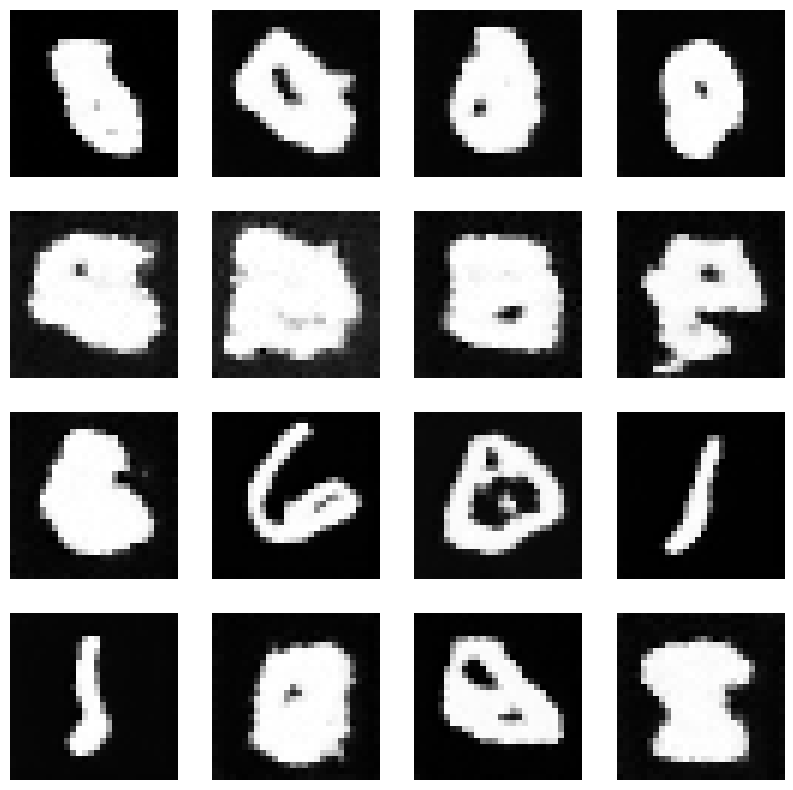

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

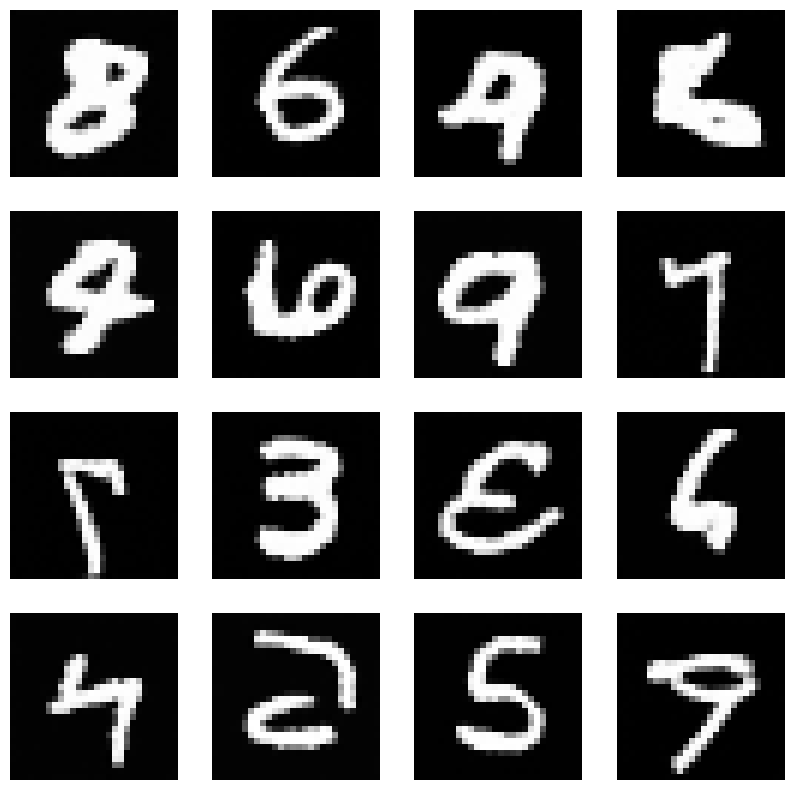

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

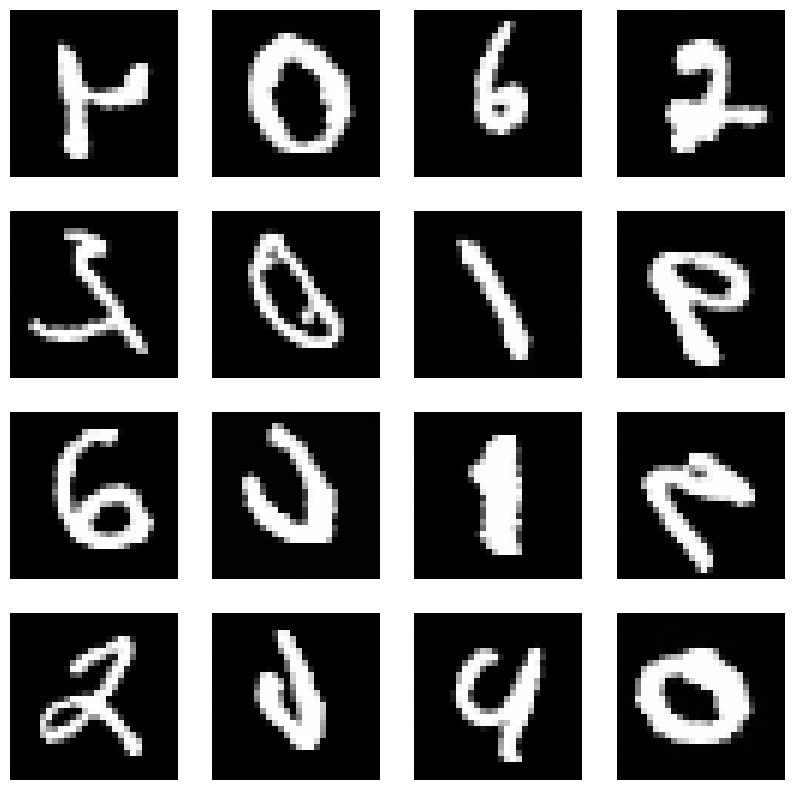

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

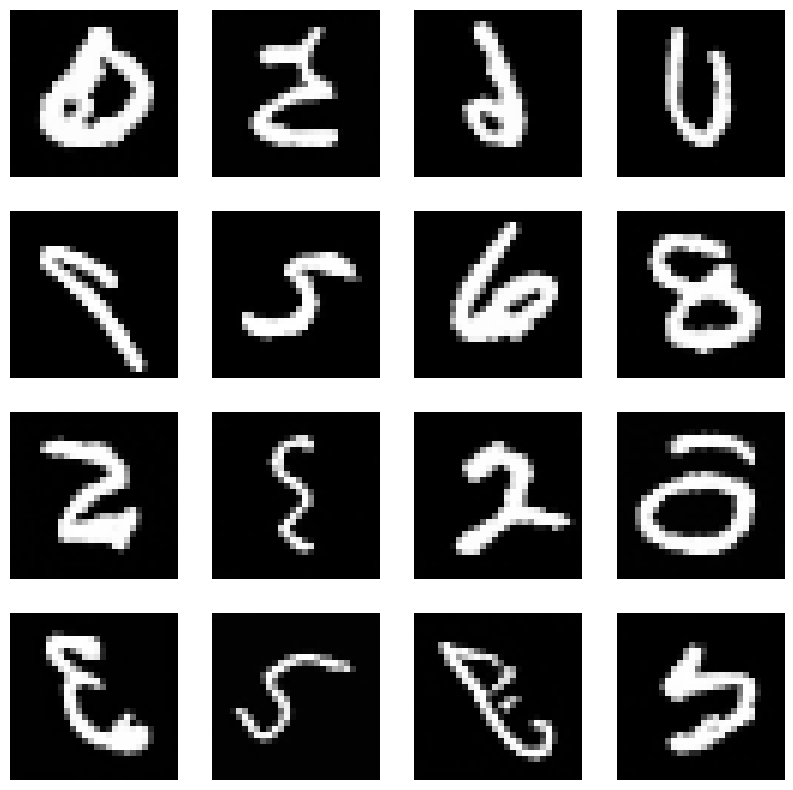

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

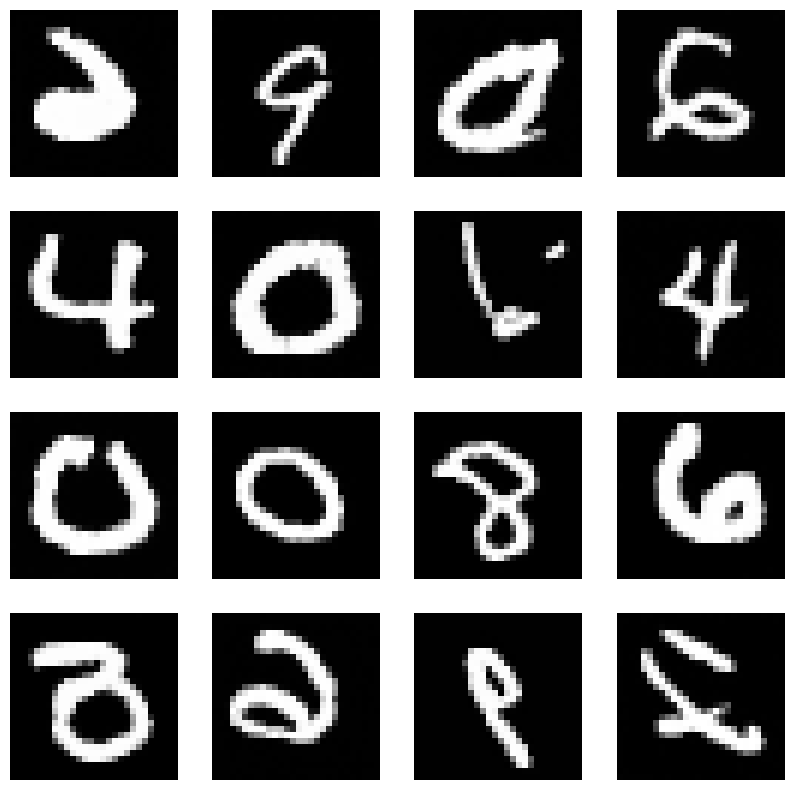

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

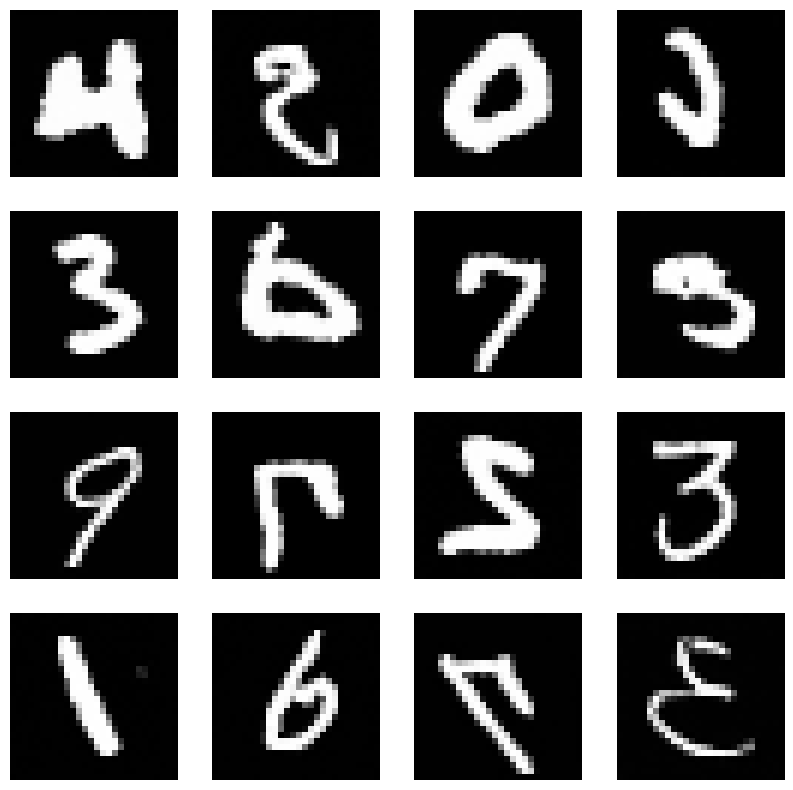

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

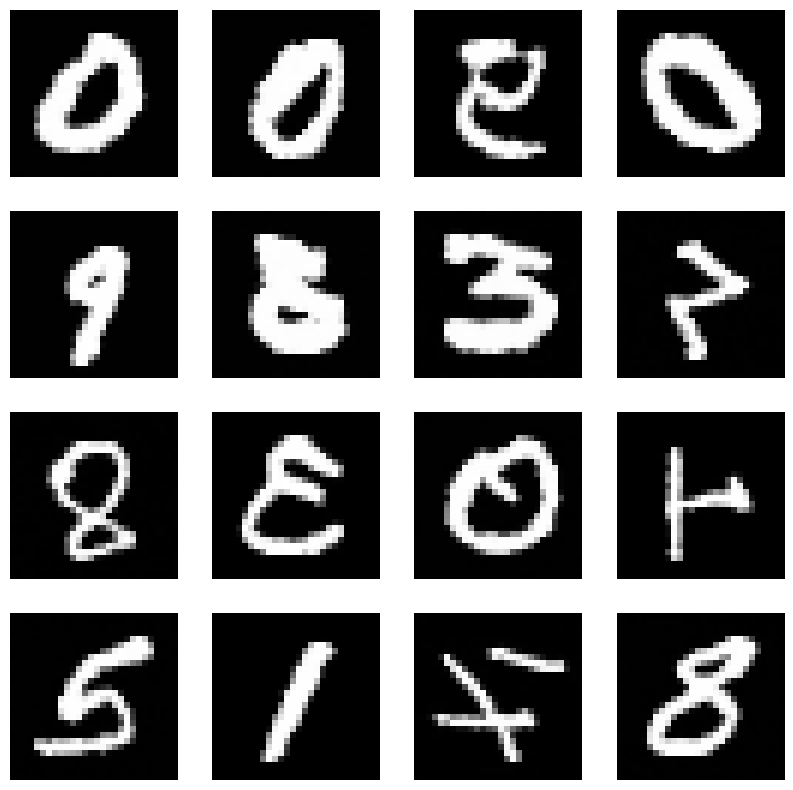

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

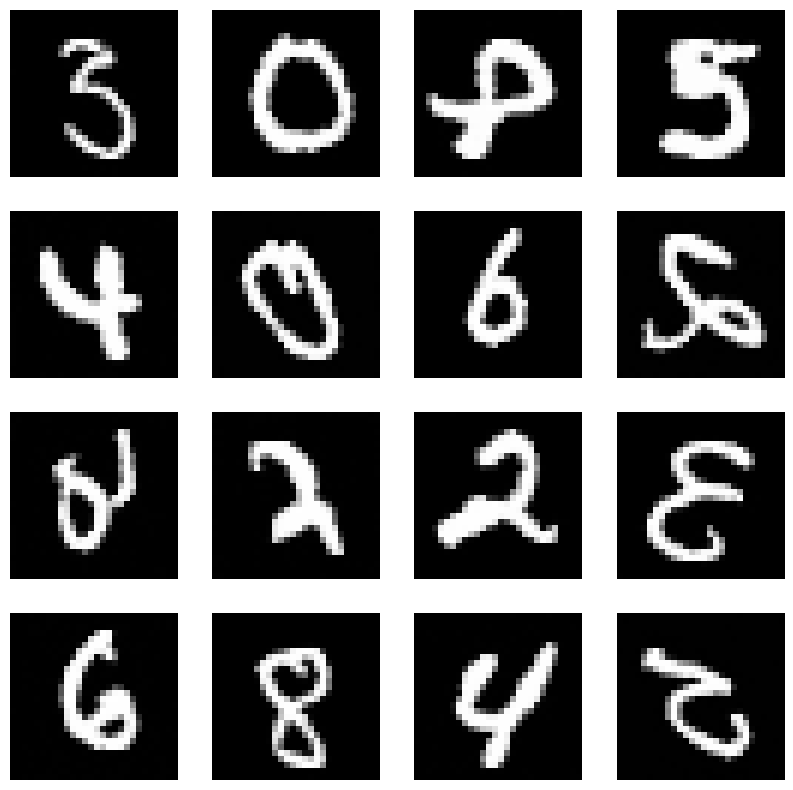

In [ ]:
from accelerate import notebook_launcher

filename = 'diffusion'
# Initialisie accelerator

accelerator = Accelerator(
        mixed_precision=config.mixed_precision,
        gradient_accumulation_steps=config.gradient_accumulation_steps,
    )

modelpath = os.path.join(config.model_output_dir, filename)
if not os.path.exists(modelpath):
    os.makedirs(modelpath)
if os.listdir(modelpath):

  # Load the pretrained model pipeline
  print("Loading pretrained model...")
  pipeline = DDPMPipeline.from_pretrained(modelpath)

  # Extract the U-Net model for further training
  model = pipeline.unet
else:
  print("Training new model...") # Launch the training loop
  args = (config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler)

  notebook_launcher(train_loop, args, num_processes=1)
  # Save the model
  if accelerator.is_main_process:
      pipeline = DDPMPipeline(unet=accelerator.unwrap_model(model), scheduler=noise_scheduler)
      pipeline.save_pretrained(modelpath)

##Alternative Training Method
If the previous block leads to error "No such file or directory: 'nvidia-smi'", please comment out and execute this block instead.


In [ ]:
"""
train_loop(config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler)
filename = 'diffusion'
# Initialisie accelerator

accelerator = Accelerator(
        mixed_precision=config.mixed_precision,
        gradient_accumulation_steps=config.gradient_accumulation_steps,
    )

modelpath = os.path.join(config.model_output_dir, filename)
if not os.path.exists(modelpath):
    os.makedirs(modelpath)


if accelerator.is_main_process:
      pipeline = DDPMPipeline(unet=accelerator.unwrap_model(model), scheduler=noise_scheduler)
      pipeline.save_pretrained(modelpath)
      """


"\ntrain_loop(config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler)\nfilename = 'diffusion'\n# Initialisie accelerator\n\naccelerator = Accelerator(\n        mixed_precision=config.mixed_precision,\n        gradient_accumulation_steps=config.gradient_accumulation_steps,\n    )\n\nmodelpath = os.path.join(config.model_output_dir, filename)\nif not os.path.exists(modelpath):\n    os.makedirs(modelpath)\n\n\nif accelerator.is_main_process:\n      pipeline = DDPMPipeline(unet=accelerator.unwrap_model(model), scheduler=noise_scheduler)\n      pipeline.save_pretrained(modelpath)\n      "

# Visualisation/Results

In this section we visualise the results from the previous training.  

  0%|          | 0/500 [00:00<?, ?it/s]

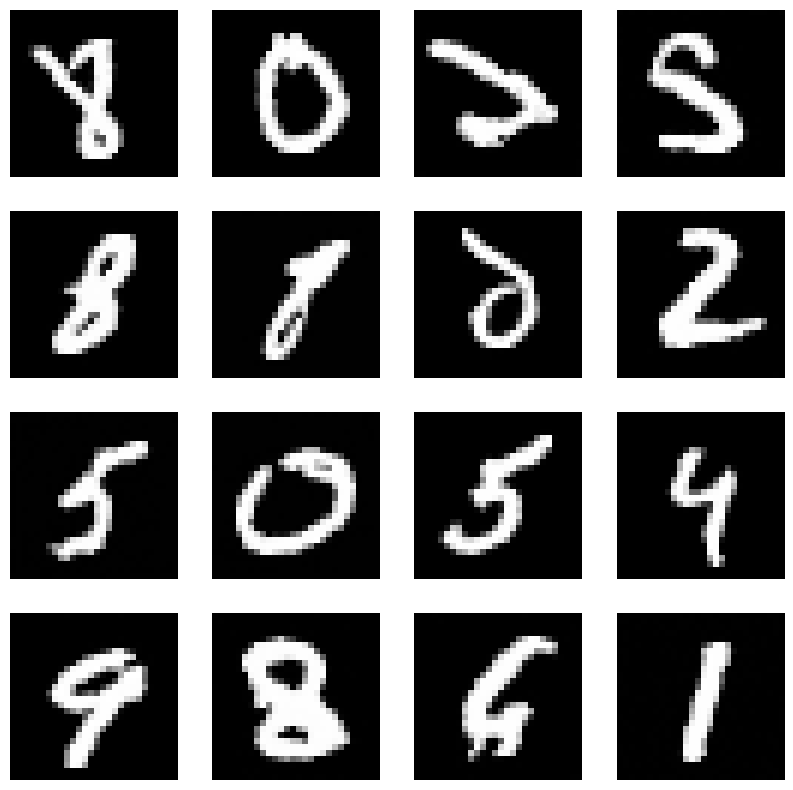

In [ ]:
# Visualise the result
# Generate some images
pipeline = DDPMPipeline(unet=accelerator.unwrap_model(model), scheduler=noise_scheduler)
images = pipeline(
        batch_size=config.eval_batch_size,
        num_inference_steps=config.num_inference_steps
    ).images
path = config.results_output_dir + "/final_example_result.png"
visualisation.show_results(images, path)

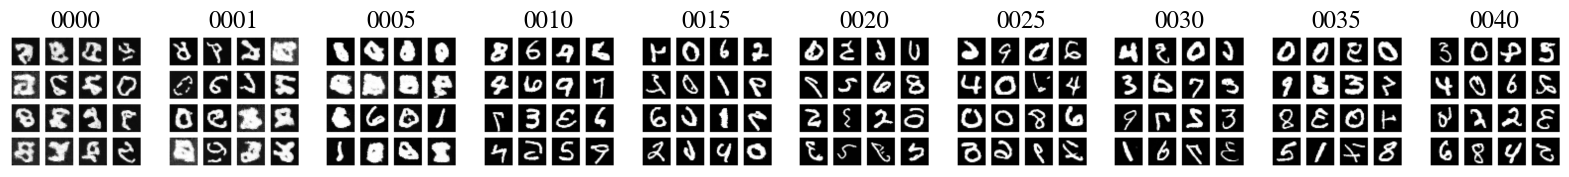

In [ ]:
import glob
# Visualise the results of the training process per iteration
#load images from result repository
sample_images = sorted(glob.glob(f"{config.results_output_dir}/training_samples/*.png"))


path = config.results_output_dir + "/training_epoch_visualisation.png"
visualisation.plot_training_visualisation(sample_images, path)


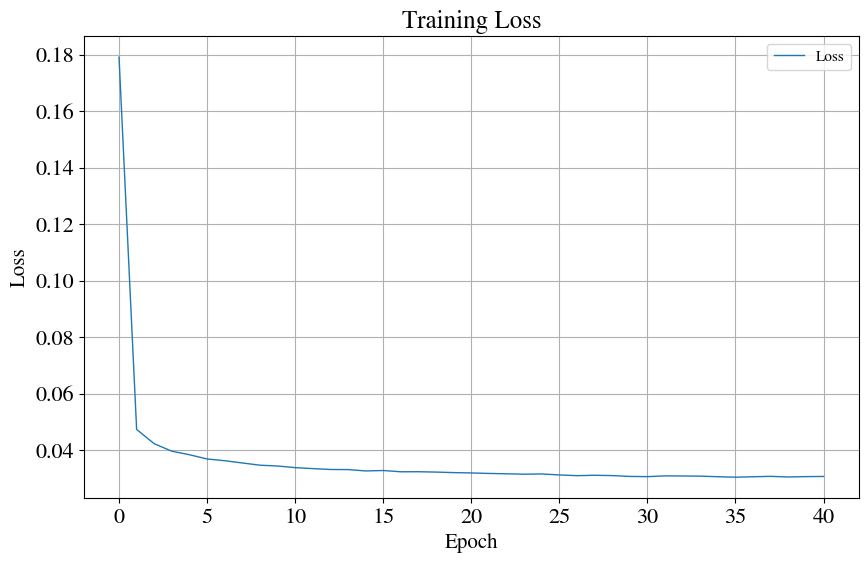

<Figure size 1500x300 with 0 Axes>

In [ ]:
# Visualise the loss
loss_path = config.results_output_dir + "/epoch_losses.json"
with open(loss_path, 'r') as f:
    losses = json.load(f)
path = config.results_output_dir + "/training_loss.png"
visualisation.plot_loss(losses, path)

Visualizing noising process for a single image.


  0%|          | 0/1 [00:00<?, ?it/s]

Image shape: (28, 28)


  0%|          | 0/5 [00:00<?, ?it/s]

Image shape: (28, 28)


...

Image shape: (28, 28)


  0%|          | 0/400 [00:00<?, ?it/s]

Image shape: (28, 28)


  0%|          | 0/500 [00:00<?, ?it/s]

Image shape: (28, 28)


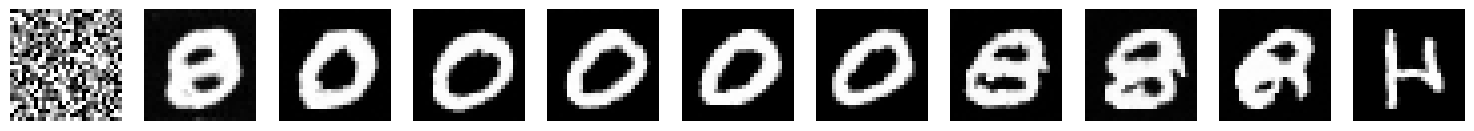

In [ ]:
# Visualise denoising process
visualisation.visualize_noising_single_image_diffusion(pipeline, config, 20)

# Optionally: Download Results
Function for Google Colab to download the model and results from local runtime.

In [ ]:
!zip -r diffusion_models.zip models
from google.colab import files
files.download('diffusion_models.zip')


  adding: models/ (stored 0%)
  adding: models/diffusion/ (stored 0%)
  adding: models/diffusion/scheduler/ (stored 0%)
  adding: models/diffusion/scheduler/scheduler_config.json (deflated 46%)
  adding: models/diffusion/unet/ (stored 0%)
  adding: models/diffusion/unet/diffusion_pytorch_model.safetensors (deflated 8%)
  adding: models/diffusion/unet/config.json (deflated 56%)
  adding: models/diffusion/model_index.json (deflated 36%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!zip -r results_diffusion.zip results
from google.colab import files
files.download('results_diffusion.zip')

  adding: results/ (stored 0%)
  adding: results/training_samples/ (stored 0%)
  adding: results/training_samples/0001.png (deflated 22%)
  adding: results/training_samples/0010.png (deflated 23%)
  adding: results/training_samples/0000.png (deflated 22%)
  adding: results/training_samples/0015.png (deflated 25%)
  adding: results/training_samples/0030.png (deflated 25%)
  adding: results/training_samples/0020.png (deflated 26%)
  adding: results/training_samples/0025.png (deflated 24%)
  adding: results/training_samples/0005.png (deflated 21%)
  adding: results/training_samples/0040.png (deflated 25%)
  adding: results/training_samples/0035.png (deflated 25%)
  adding: results/epoch_losses.json (deflated 56%)
  adding: results/training_loss.png (deflated 91%)
  adding: results/final_example_result.png (deflated 26%)
  adding: results/training_epoch_visualisation.png (deflated 12%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>